<b>Введение</b>
Цель работы: изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.
Постановка задачи:

Провести обучение модели линейной регрессии на датасете с Kaggle:

Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).

Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.

Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).

Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).

Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).

Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA). Перед проведением PCA провести стандартизацию данных.

Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

Описание датасета
Выбранный датасет: влияние факторов(карат, цвет, огранка, прозрачность, размер, глубина, ширина поверхности) на стоимость бриллианта.
С помощью кода, представленного ниже были получены графики рапределения признаков и целевой переменной(цены) и  корреляционая матрица.

Размер датасета: (1002, 10)

Первые строки:
   carat  cut  color  clarity  depth  table  price     x     y     z
0   0.23    5      6        2   61.5   55.0    326  3.95  3.98  2.43
1   0.21    4      6        3   59.8   61.0    326  3.89  3.84  2.31
2   0.23    2      6        5   56.9   65.0    327  4.05  4.07  2.31
3   0.29    4      2        4   62.4   58.0    334  4.20  4.23  2.63
4   0.31    2      1        2   63.3   58.0    335  4.34  4.35  2.75

Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    1002 non-null   float64
 1   cut      1002 non-null   int8   
 2   color    1002 non-null   int8   
 3   clarity  1002 non-null   int8   
 4   depth    1002 non-null   float64
 5   table    1002 non-null   float64
 6   price    1002 non-null   int64  
 7   x        1002 non-null   float64
 8   y        1002 non-null   float64
 9   z

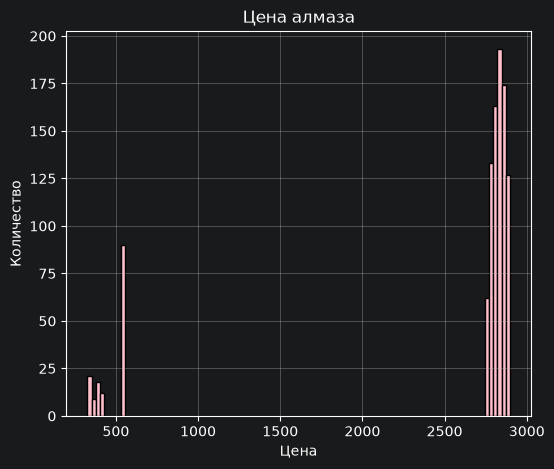

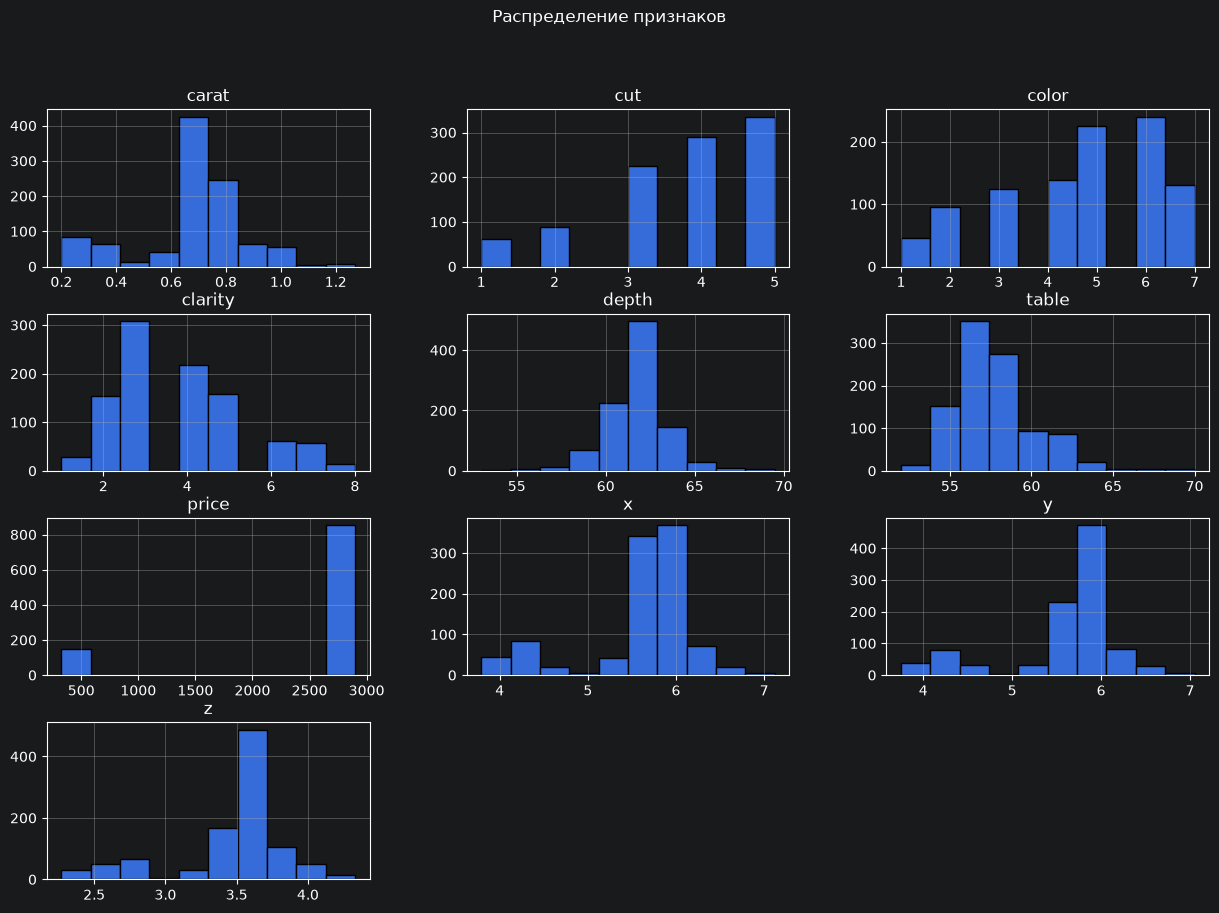

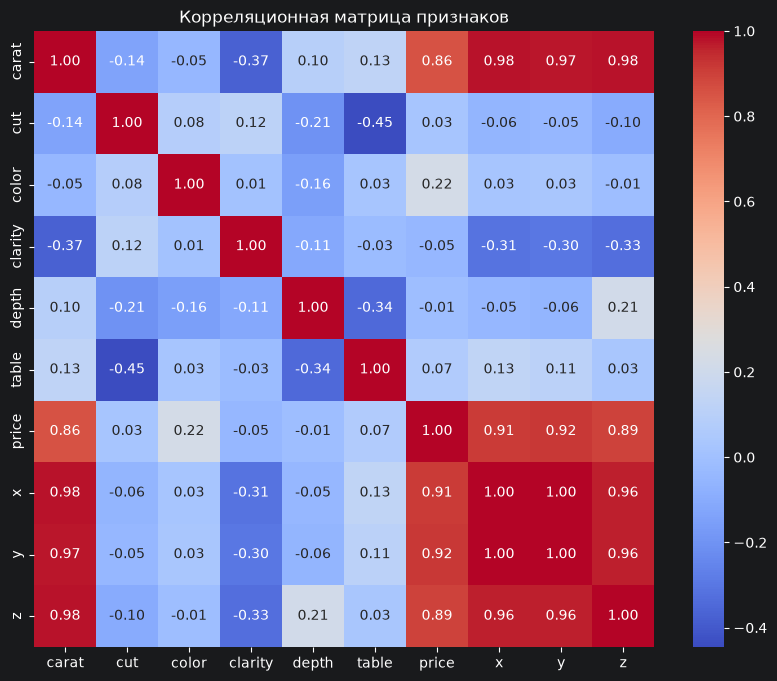

            carat       cut     color   clarity     depth     table     price  \
carat    1.000000 -0.135786 -0.048842 -0.373948  0.095567  0.126415  0.857590   
cut     -0.135786  1.000000  0.081260  0.118582 -0.207052 -0.445238  0.027980   
color   -0.048842  0.081260  1.000000  0.007199 -0.156698  0.028810  0.222858   
clarity -0.373948  0.118582  0.007199  1.000000 -0.113351 -0.027440 -0.045953   
depth    0.095567 -0.207052 -0.156698 -0.113351  1.000000 -0.344946 -0.012163   
table    0.126415 -0.445238  0.028810 -0.027440 -0.344946  1.000000  0.067292   
price    0.857590  0.027980  0.222858 -0.045953 -0.012163  0.067292  1.000000   
x        0.977597 -0.056105  0.026311 -0.311536 -0.049944  0.132024  0.911171   
y        0.972584 -0.045943  0.030287 -0.300587 -0.058115  0.112203  0.917205   
z        0.980879 -0.104552 -0.013101 -0.328230  0.211665  0.031089  0.892967   

                x         y         z  
carat    0.977597  0.972584  0.980879  
cut     -0.056105 -0.045943 

In [2]:
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import seaborn as sns
import numpy as np

df = pd.read_csv("diamonds.csv", sep=",")
df.drop('Unnamed: 0', axis=1, inplace=True)
order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
df['cut'] = pd.Categorical(df["cut"], categories=order, ordered=True).codes + 1
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]
df['color'] = pd.Categorical(df["color"], categories=color_order, ordered=True).codes + 1
df['clarity'] = pd.Categorical(df["clarity"], categories=clarity_order, ordered=True).codes + 1

print("Размер датасета:", df.shape)
print("\nПервые строки:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nОписание признаков:")
print(df.describe())

print("\nКоличество пропусков:")
print(df.isnull().sum())

numeric_columns = df.select_dtypes(include=[np.number]).columns

data = {
    'Параметр': [],
    'Асимметрия': [],
    'Эксцесс': []
}

for col in numeric_columns:
    skew_val = skew(df[col].dropna())
    kurt_val = kurtosis(df[col].dropna())
    data['Параметр'].append(col)
    data['Асимметрия'].append(skew_val)
    data['Эксцесс'].append(kurt_val)

summary_df = pd.DataFrame(data)
print(summary_df)
count_of_bins = int(1 + 3.322*math.log10(df.shape[0]))

plt.figure(figsize=(6,5))
df['price'].hist(bins=100,edgecolor="black",color="pink")
plt.ylabel('Количество')
plt.xlabel('Цена')
plt.title("Цена алмаза")
plt.show()

df.hist(bins=count_of_bins, figsize=(15,10), edgecolor="black")
plt.suptitle("Распределение признаков")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица признаков")
plt.show()

print(df.corr())

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv("diamonds.csv", sep=",")
df.drop('Unnamed: 0', axis=1, inplace=True)
order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
df['cut'] = pd.Categorical(df["cut"], categories=order, ordered=True).codes + 1
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]
df['color'] = pd.Categorical(df["color"], categories=color_order, ordered=True).codes + 1
df['clarity'] = pd.Categorical(df["clarity"], categories=clarity_order, ordered=True).codes + 1

X = df.drop("price", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

vif_data = pd.DataFrame()
vif_data["Переменная"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

  Переменная          VIF
8          z  1218.502616
6          x   442.521704
7          y   423.972875
4      depth    85.293987
0      carat    70.938940
5      table     1.927184
1        cut     1.616569
3    clarity     1.386828
2      color     1.224438
